In [1]:
from runsims_FNL import * 

-----------------------------------------------------
SarahLibanore: developed f_nl in IC and fcoll, fixed on 08/04/2026
-----------------------------------------------------


In [15]:
Lbox_fid = 100
Nbox_fid = 100

Fiducial case:
- Edgeworth expression in dNion_General
- D'Alosio expression in dNdm_conditional
- Only popII 
- Scale-independent fnl
- Max cut at log10 M = 12

Let's first run the Gaussian case in the fiducial setup

In [17]:
Gauss = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = 0., 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,Gaus_Mcut12.0.pkl
Running...
Now running CLASS...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [12:16<00:00,  8.76s/redshift]


# Test 1: Gaussian vs Non-Gaussian in our fiducial scenario

Compare:

- Gauss
- Non-Gauss

using a test value of fnl

In [3]:
fnl_test = 200.

In [16]:
NG = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,200.0_Mcut12.0.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [42:22<00:00, 30.26s/redshift]   


In [18]:
NGm = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,-200.0_Mcut12.0.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [13:19<00:00,  9.51s/redshift]


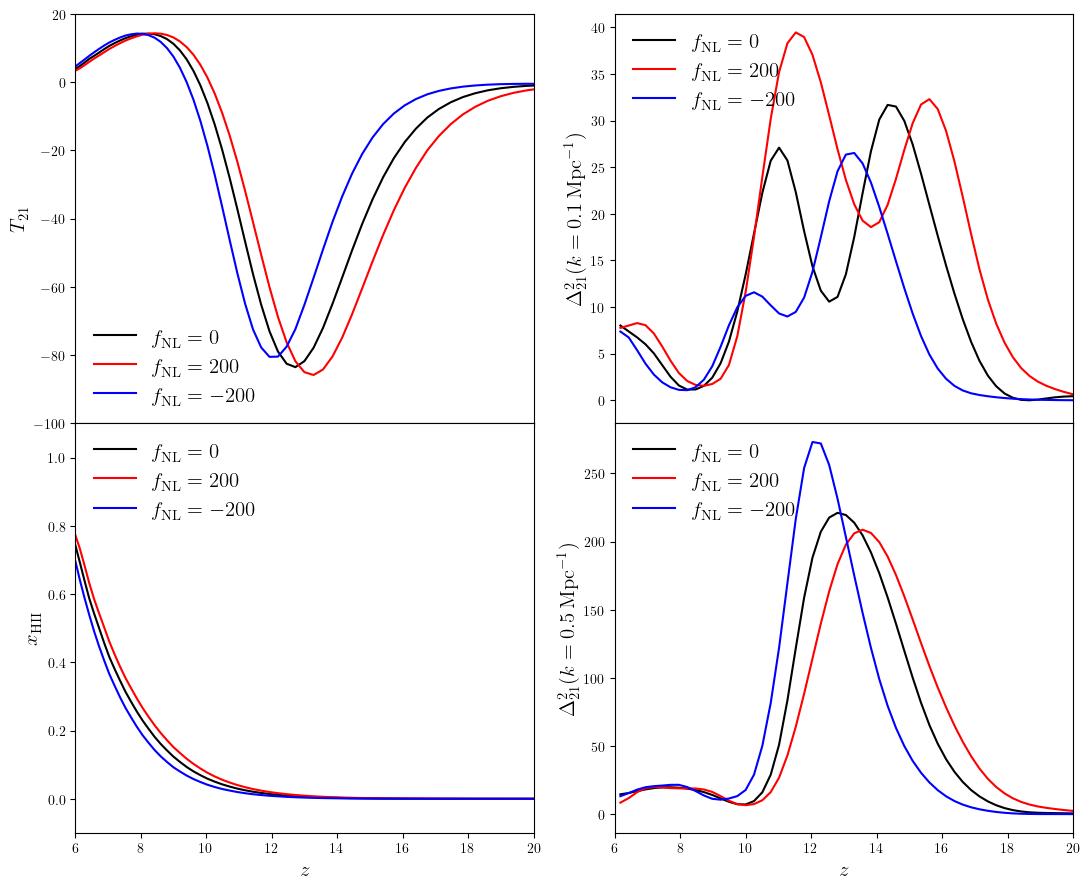

In [19]:
compare = [Gauss, NG, NGm]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'b'],
                    list_ls = ['-', '-','-'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$f_{\rm NL}=%g$'%(-fnl_test)
                    ], 
                    filename = 'compare_NG_fiducial_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

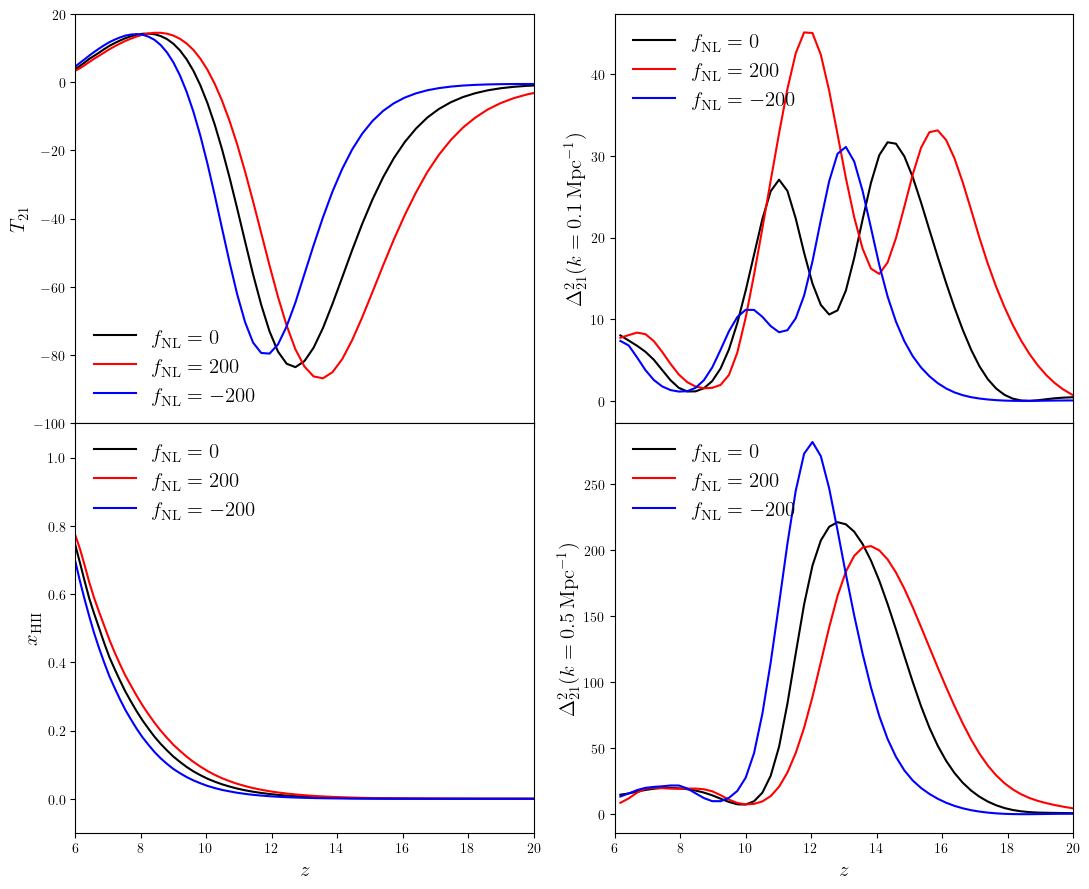

In [7]:
compare = [Gauss, NG, NGm]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'b'],
                    list_ls = ['-', '-','-'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$f_{\rm NL}=%g$'%(-fnl_test)
                    ], 
                    filename = 'compare_NG_fiducial_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

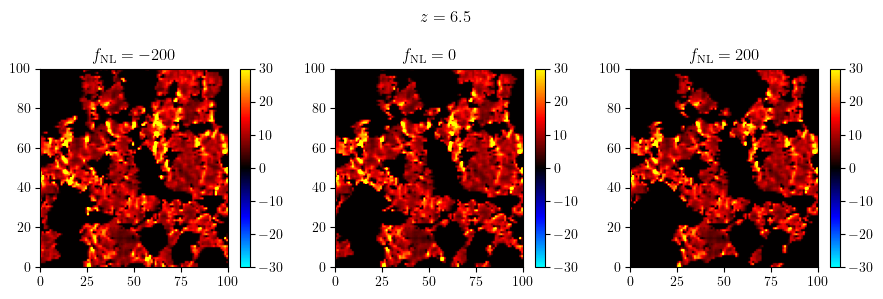

In [20]:
plot_compare_boxes(0,100,compare,                    
                   list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$f_{\rm NL}=%g$'%(-fnl_test)
                    ], 
                    filename = 'boxes_NG_fiducial_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

# Test 2: Contributions to the Non-Gaussian correction

Compare:
- Gauss
- Non-Gauss only IC
- Non-Gauss only dNion_General
- Non-Gauss only dNdm


In [9]:
NG_IC = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [10]:
NGm_IC = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [11]:
NG_dNion_General = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [12]:
NGm_dNion_General = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [13]:
NG_dNdm_cond = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [14]:
NGm_dNdm_cond = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

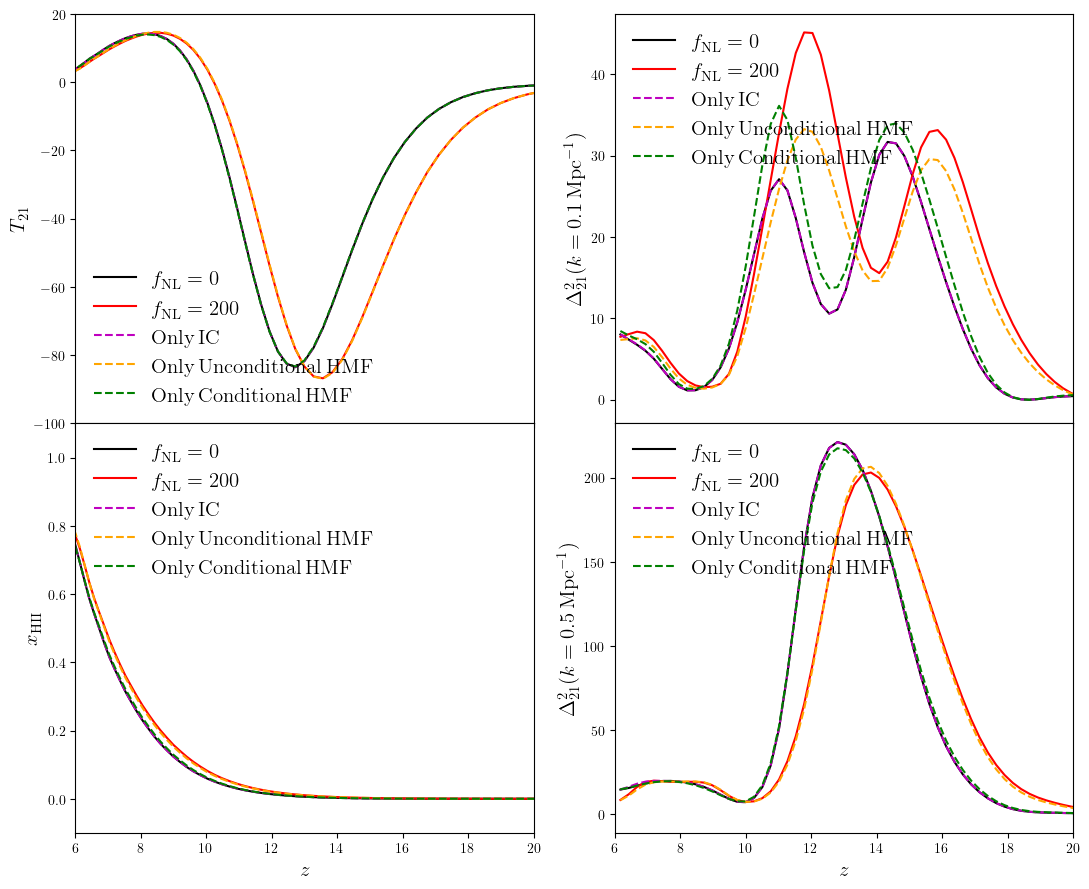

In [15]:
compare = [Gauss, NG, NG_IC, NG_dNion_General, NG_dNdm_cond]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'm', 'orange','g'],
                    list_ls = ['-', '-','--','--','--'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$\rm Only\,IC$',
                        r'$\rm Only\,Unconditional\,HMF$',
                        r'$\rm Only\,Conditional\,HMF$'
                    ], 
                    filename = 'compare_NG_components_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')



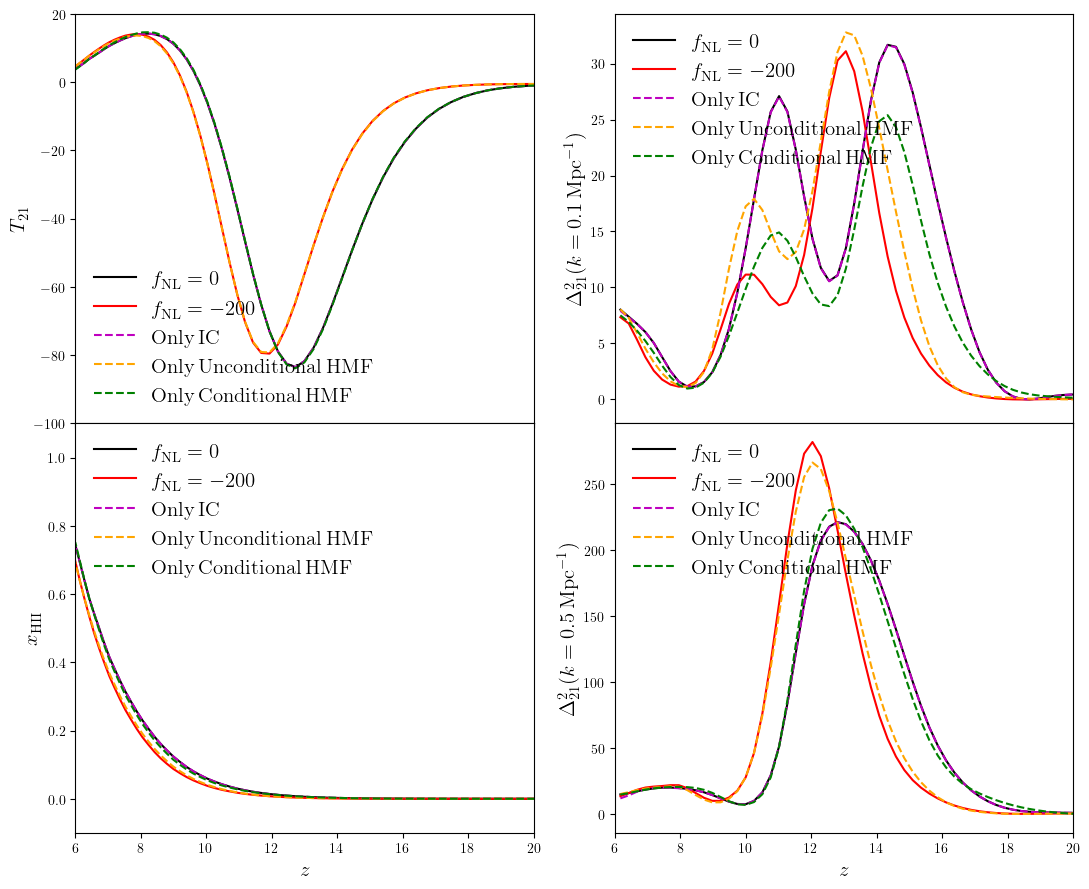

In [16]:
compare = [Gauss, NGm, NGm_IC, NGm_dNion_General, NGm_dNdm_cond]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'm', 'orange','g'],
                    list_ls = ['-', '-','--','--','--'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%(-fnl_test),
                        r'$\rm Only\,IC$',
                        r'$\rm Only\,Unconditional\,HMF$',
                        r'$\rm Only\,Conditional\,HMF$'
                    ], 
                    filename = 'compare_NG_components_neg_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

# Test 3: Saddlepoint comparison

Compare:
- Gausss
- Non-Gaus only dNion_General with Edgeworth (fid)
- Non-Gaus only dNion_General with saddlepoint 

and 
- Gauss
- Non-Gaus only dNdm with LD (fid)
- Non-Gaus only dNdm with saddlepoint 

In [17]:
NG_dNion_General_saddle = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = False, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [18]:
NGm_dNion_General_saddle = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = False, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [19]:
NG_dNdm_cond_saddle = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = False, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [20]:
NGm_dNdm_cond_saddle = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = False, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

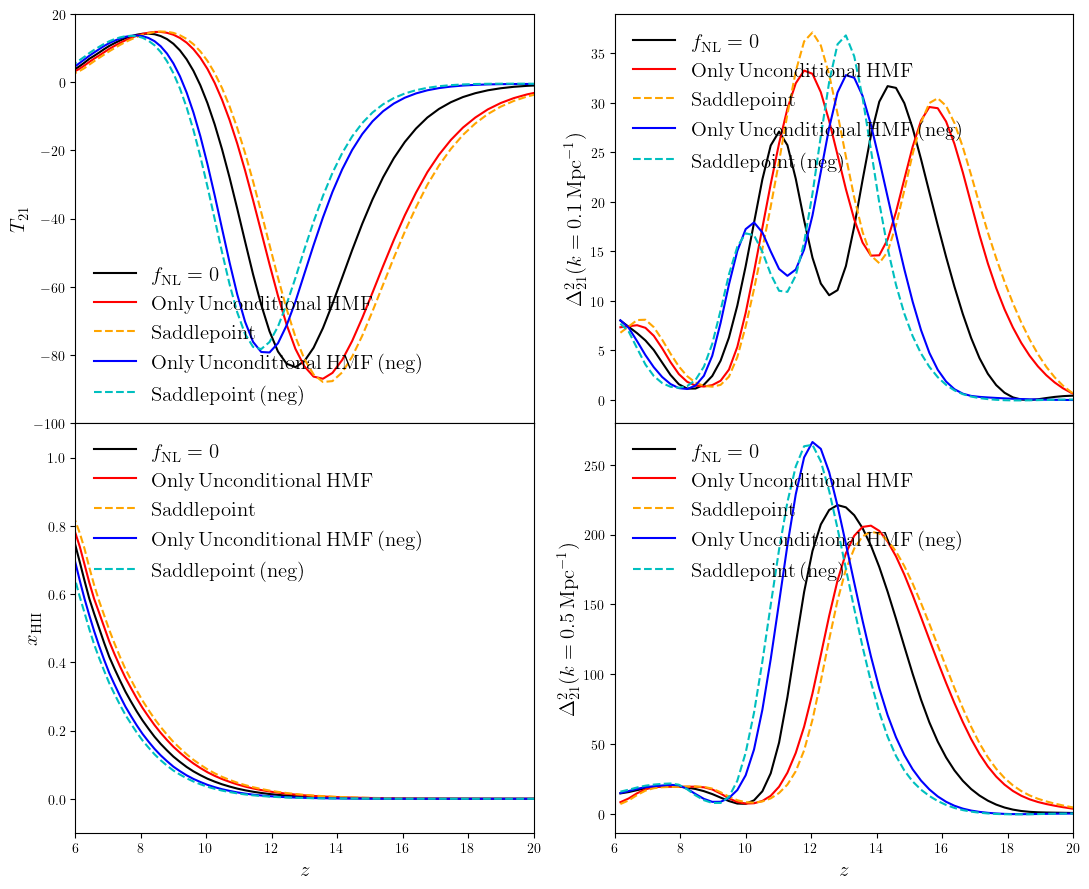

In [21]:
compare = [Gauss, NG_dNion_General, NG_dNion_General_saddle, NGm_dNion_General, NGm_dNion_General_saddle]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'orange', 'b', 'c'],
                    list_ls = ['-', '-','--','-','--'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$\rm Only\,Unconditional\,HMF$',
                        r'$\rm Saddlepoint$',
                        r'$\rm Only\,Unconditional\,HMF \,(neg)$',
                        r'$\rm Saddlepoint\,(neg)$'
                    ], 
                    filename = 'compare_unconditional_saddle_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

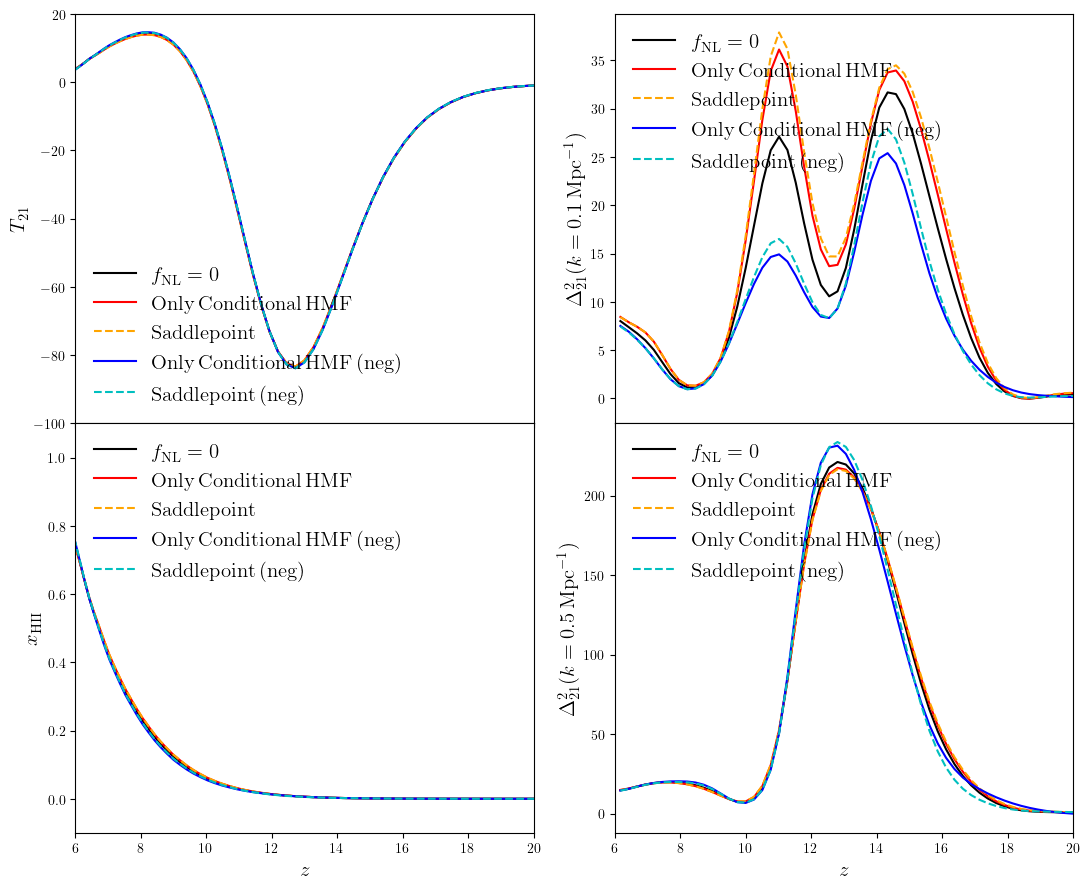

In [22]:
compare = [Gauss, NG_dNdm_cond, NG_dNdm_cond_saddle, NGm_dNdm_cond, NGm_dNdm_cond_saddle]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'orange','b','c'],
                    list_ls = ['-', '-','--','-','--'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$\rm Only\,Conditional\,HMF$',
                        r'$\rm Saddlepoint$',
                        r'$\rm Only\,Conditional\,HMF \,(neg)$',
                        r'$\rm Saddlepoint\,(neg)$'
                    ], 
                    filename = 'compare_conditional_saddle_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

# Test 4: Lidz vs D'Alosio

Compare:
- Gauss
- Non-Gauss conditional in D'Alosio (fid)
- Non-Gauss conditional in Lidz


In [23]:
NG_dNdm_cond_Lidz = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = True, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [24]:
NGm_dNdm_cond_Lidz = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = True, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

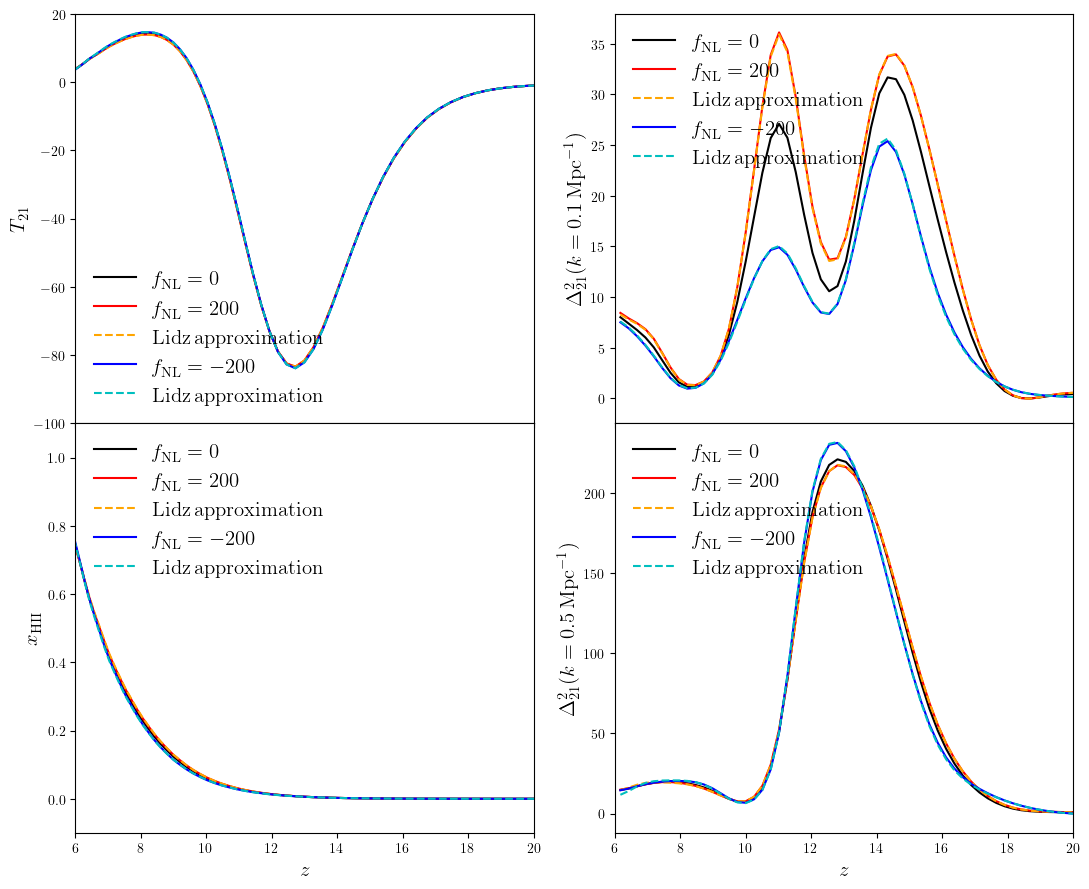

In [25]:
compare = [Gauss, NG_dNdm_cond, NG_dNdm_cond_Lidz, NGm_dNdm_cond, NGm_dNdm_cond_Lidz]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'orange', 'b', 'c'],
                    list_ls = ['-', '-','--' ,'-','--'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$\rm Lidz\,approximation$',
                        r'$f_{\rm NL}=%g$'%(-fnl_test),
                        r'$\rm Lidz\,approximation$'
                    ], 
                    filename = 'compare_LidzDAl_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

# Test 5: CutOff Mass

Compare: 
- Gauss cut off at log10 M = 12 (fid)
- Gauss integrated over the full mass array
- Non-Gauss cut off at log10 M = 12 (fid)
- Non-Gauss cut off at log10 M = 14
- Non-Gauss integrated over the full mass array

In [26]:
Gauss_full = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = 0., 
            force_mmax = 0., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

In [27]:
NG_14 = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 14., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,200.0_Mcut14.0.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [13:35<00:00,  9.71s/redshift]


In [28]:
NGm_14 = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 14., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,-200.0_Mcut14.0.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [13:27<00:00,  9.61s/redshift]


In [29]:
NG_full = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 0., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,200.0.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [13:24<00:00,  9.57s/redshift]


In [30]:
NGm_full = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 0., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

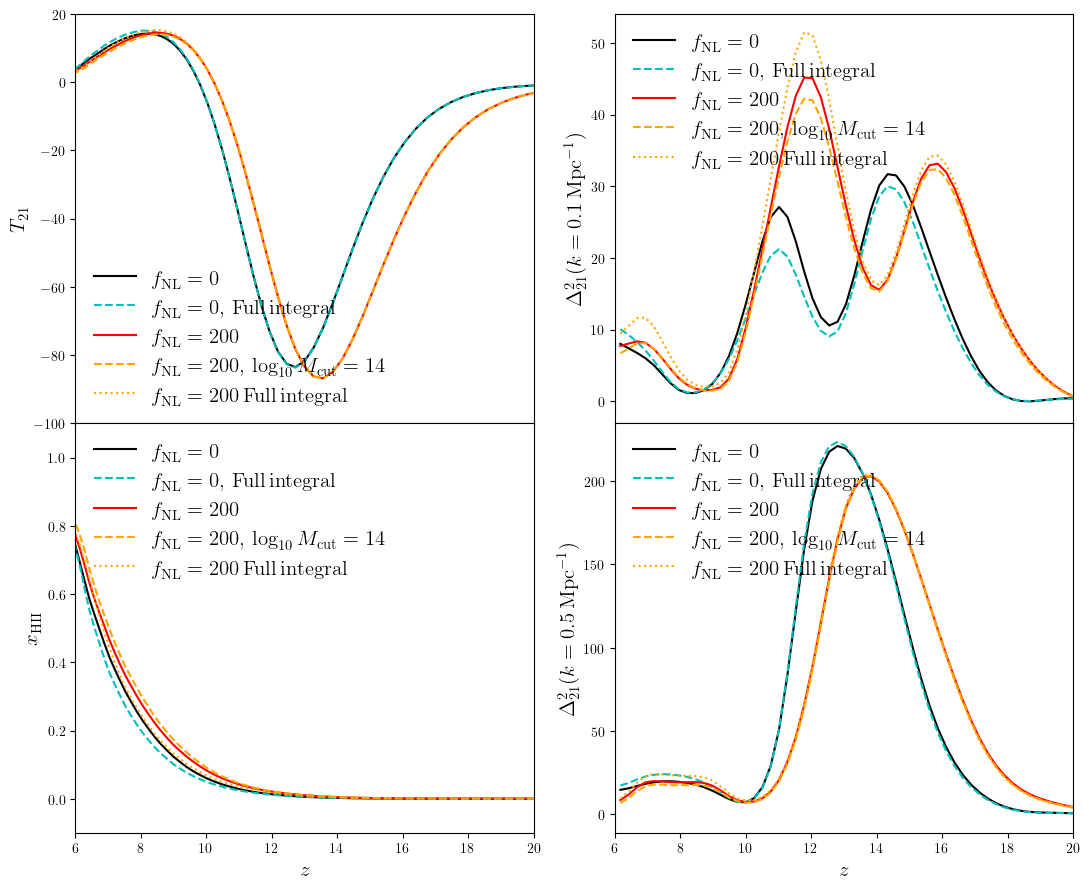

In [51]:
compare = [Gauss, Gauss_full, NG, NG_14, NG_full]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'c', 'r', 'orange','orange'],
                    list_ls = ['-', '--','-','--',':'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=0,\,\rm Full\,integral$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$f_{\rm NL}=%g,\,\log_{10}M_{\rm cut}=14$'%fnl_test,
                        r'$f_{\rm NL}=%g\,\rm Full\,integral$'%fnl_test,
                    ], 
                    filename = 'compare_Mcutoff_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

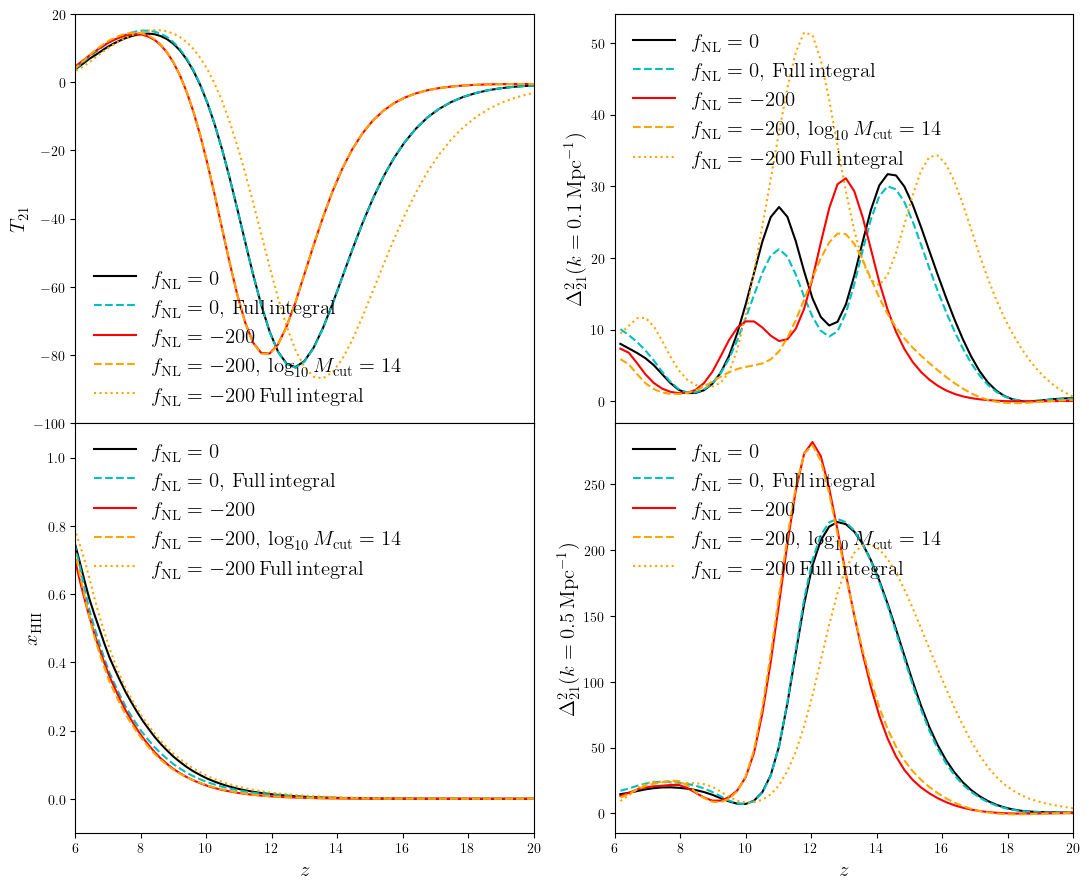

In [52]:
compare = [Gauss, Gauss_full, NGm, NGm_14, NGm_full]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'c', 'r', 'orange','orange'],
                    list_ls = ['-', '--','-','--',':'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=0,\,\rm Full\,integral$',
                        r'$f_{\rm NL}=%g$'%(-fnl_test),
                        r'$f_{\rm NL}=%g,\,\log_{10}M_{\rm cut}=14$'%(-fnl_test),
                        r'$f_{\rm NL}=%g\,\rm Full\,integral$'%(-fnl_test),
                    ], 
                    filename = 'compare_Mcutoff_neg_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

# Test 6: cutoff scale

Compare:
- Gauss
- Non-Gauss with kcut = 1e-3 (fid)
- Non-Gauss with kcut = 0.1 
- Non-Gauss with kcut = 0.5 
- Non-Gauss with kcut = 1 

Fig. 4 in 2009.01245

In [33]:
NG_01 = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 0.1, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,200.0_Mcut12.0_Kcut0.1.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [13:34<00:00,  9.70s/redshift]


In [34]:
NGm_01 = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 0.1, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,-200.0_Mcut12.0_Kcut0.1.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [13:11<00:00,  9.42s/redshift]


In [35]:
NG_05 = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 0.5, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,200.0_Mcut12.0_Kcut0.5.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [13:23<00:00,  9.57s/redshift]


In [36]:
NGm_05 = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 0.5, 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,-200.0_Mcut12.0_Kcut0.5.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [12:58<00:00,  9.27s/redshift]


In [37]:
NG_1 = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1., 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,200.0_Mcut12.0_Kcut1.0.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [13:06<00:00,  9.36s/redshift]


In [38]:
NGm_1 = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = -fnl_test, 
            force_mmax = 12., 
            kcut_fnl = 1., 
            USE_MINI_HALOS = False, 
            nongauss_IC = True, 
            nongauss_fcollcond = True, 
            nongauss_fcolluncond = True, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

File not found: ./final_test/100,100,-200.0_Mcut12.0_Kcut1.0.pkl
Running...
Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...
Now going through the dark ages...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [12:55<00:00,  9.23s/redshift]


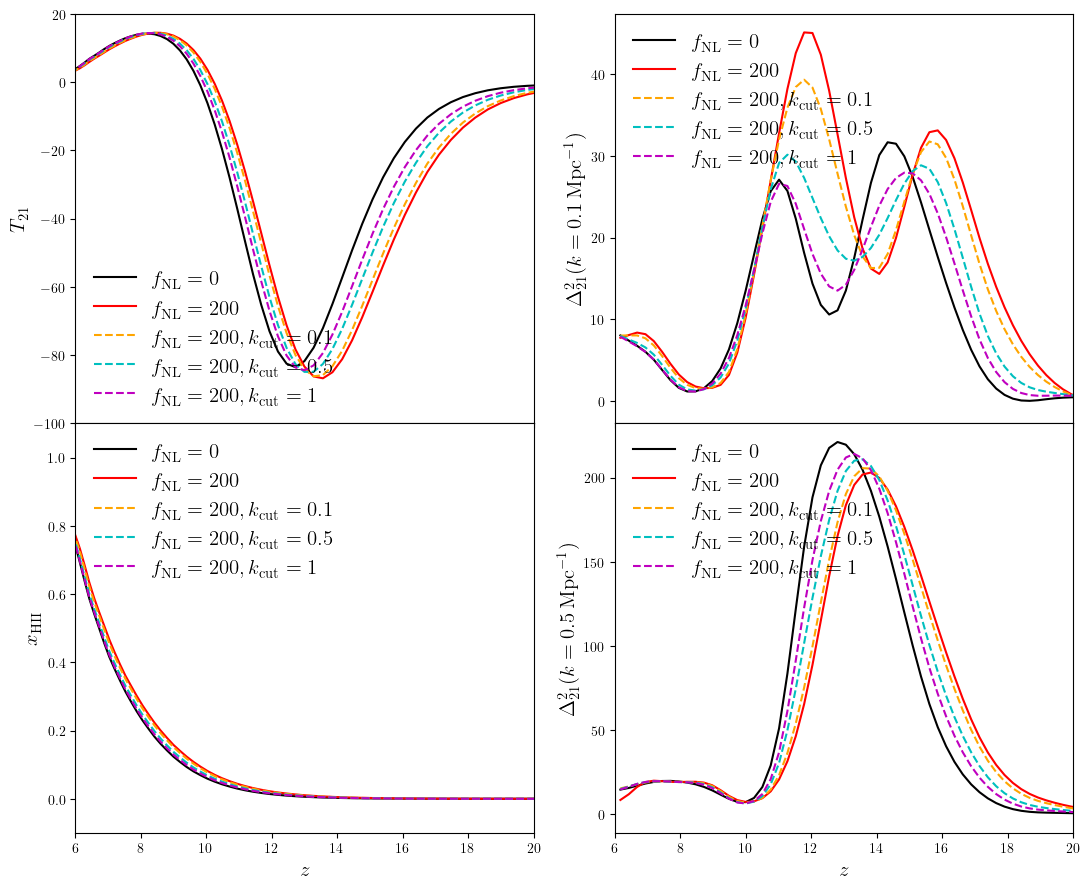

In [39]:
compare = [Gauss, NG, NG_01, NG_05, NG_1]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'orange','c','m'],
                    list_ls = ['-', '-','--','--','--'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%fnl_test,
                        r'$f_{\rm NL}=%g,k_{\rm cut}=0.1$'%fnl_test,
                        r'$f_{\rm NL}=%g,k_{\rm cut}=0.5$'%fnl_test,
                        r'$f_{\rm NL}=%g,k_{\rm cut}=1$'%fnl_test,
                    ], 
                    filename = 'compare_kcutoff_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')



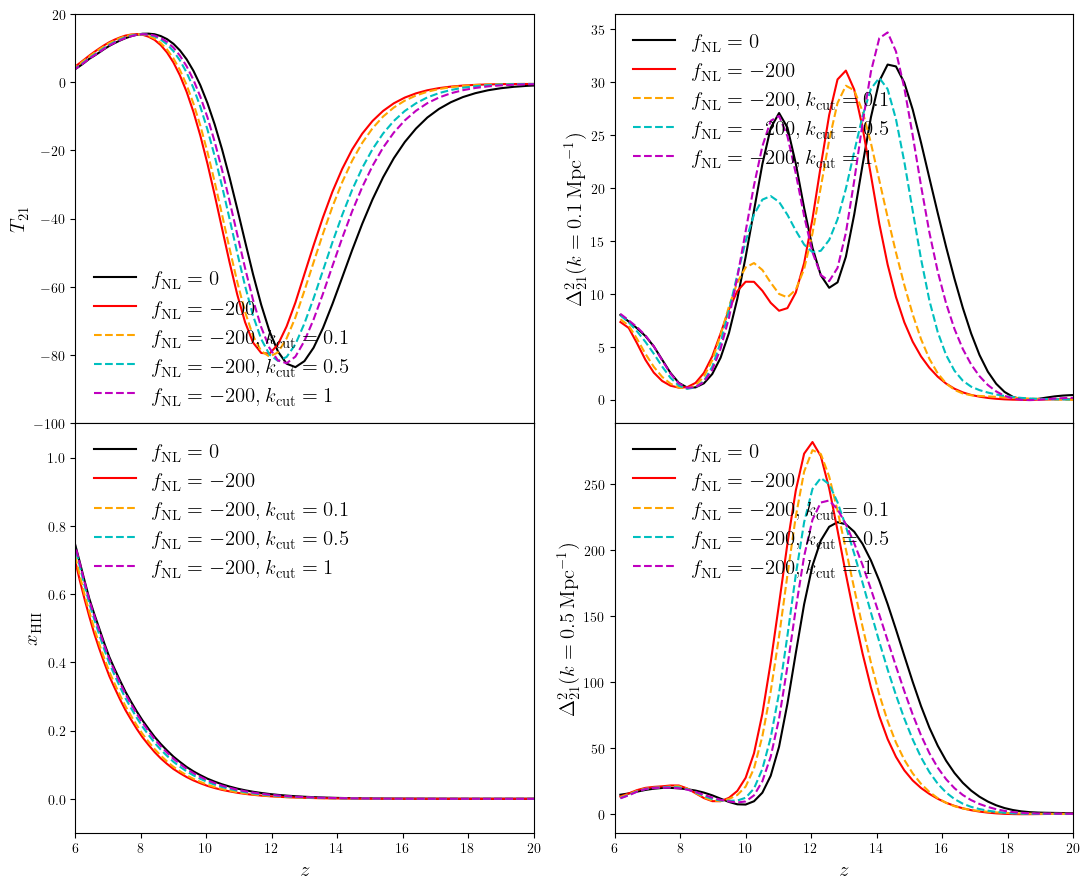

In [40]:
compare = [Gauss, NGm, NGm_01, NGm_05, NGm_1]

plot_compare_multi(k_vals = [0.1,0.5], 
                    list_to_compare = compare,
                    list_colors = ['k', 'r', 'orange','c','m'],
                    list_ls = ['-', '-','--','--','--'],
                    list_labels = [
                        r'$f_{\rm NL}=0$',
                        r'$f_{\rm NL}=%g$'%(-fnl_test),
                        r'$f_{\rm NL}=%g,k_{\rm cut}=0.1$'%(-fnl_test),
                        r'$f_{\rm NL}=%g,k_{\rm cut}=0.5$'%(-fnl_test),
                        r'$f_{\rm NL}=%g,k_{\rm cut}=1$'%(-fnl_test),
                    ], 
                    filename = 'compare_kcutoff_neg_' + str(Lbox_fid) + ',' + str(Nbox_fid) + '.png')

To show the dependence on kcut.

In [41]:
from scipy.interpolate import interp1d
from classy import Class
from py21cmfast.generate_ICs import Interpolate_transfer

log10_mass_array = np.linspace(4.,20.,300)
Mh = pow(10.,log10_mass_array)

LOG_K_ARR_FOR_TRANSFERS = [-5.15144838, -5.0514484 , -4.95144828, -4.85144824, -4.75144831,
    -4.65144846, -4.55144842, -4.45144844, -4.35144836, -4.2514484 ,
    -4.15144838, -4.0514484 , -3.95144828, -3.85144824, -3.75144831,
    -3.65144846, -3.55144842, -3.45144844, -3.35144836, -3.2514484 ,
    -3.15144838, -3.0514484 , -2.95144828, -2.85144824, -2.75144831,
    -2.65144846, -2.55144842, -2.45144844, -2.35144836, -2.2514484 ,
    -2.15144838, -2.0514484 , -1.95144828, -1.85144855, -1.75145051,
    -1.65167858, -1.55757323, -1.49148227, -1.44915893, -1.41712202,
    -1.39038991, -1.36686022, -1.34546231, -1.3255776 , -1.30681547,
    -1.28891354, -1.27168632, -1.25499794, -1.23874561, -1.22284979,
    -1.20724751, -1.19188819, -1.17673058, -1.1617405 , -1.14688964,
    -1.13215425, -1.11751423, -1.1029525 , -1.08845468, -1.07400858,
    -1.05960376, -1.04523159, -1.0308847 , -1.01655703, -1.00224362,
    -0.98794056, -0.97364449, -0.95935297, -0.9450646 , -0.93077752,
    -0.91649165, -0.90220562, -0.88792009, -0.87363446, -0.85934868,
    -0.84506291, -0.83077684, -0.81649043, -0.80220246, -0.78791232,
    -0.7736182 , -0.75931799, -0.74500867, -0.73068674, -0.71634763,
    -0.70198555, -0.6875937 , -0.67316396, -0.65868698, -0.64415096,
    -0.6295428 , -0.61484684, -0.60004451, -0.58511402, -0.57002998,
    -0.5547616 , -0.53927245, -0.5235185 , -0.50744591, -0.49098831,
    -0.47406185, -0.45656015, -0.43834405, -0.41922757, -0.39895473,
    -0.3771609 , -0.35330423, -0.32653792, -0.29545819, -0.25758495,
    -0.20836373, -0.14039666, -0.05026523,  0.04900858,  0.1489976 ,
    0.24899768,  0.34899762,  0.44899771,  0.54899762,  0.64899771,
    0.7489977 ,  0.84899769,  0.94899765,  1.04899772,  1.1489976 ,
    1.24899768,  1.34899762,  1.44899771,  1.54899762,  1.64899771,
    1.7489977 ,  1.84899769,  1.94899765,  2.04899772,  2.1489976 ,
    2.24899768,  2.34899762,  2.44899771,  2.54899762,  2.64899771,
    2.7489977 ,  2.84899769,  2.94899765,  3.04899772]

hlittle = 0.6736
OMm = 0.3153
OMb = 0.0493
A_s = 2.1e-9
POWER_INDEX = 0.9649
tau_reio = 0.0544
Tcmb0 = 2.728 

CLASS_params = {}
CLASS_params['h'] = hlittle
CLASS_params['Omega_cdm'] = OMm - OMb 
CLASS_params['Omega_b'] = OMb
CLASS_params['A_s'] = A_s
CLASS_params['n_s'] = POWER_INDEX
CLASS_params['tau_reio'] = tau_reio
CLASS_params['T_cmb'] = Tcmb0
CLASS_params['m_ncdm'] = "0.06" # eV
CLASS_params['N_ncdm'] = 1
CLASS_params['N_ur'] = 2.0308
CLASS_params['output'] = 'tCl,pCl,lCl,mTk,vTk,mPk'
CLASS_params['lensing'] = 'yes'
CLASS_params['z_pk'] = 1087.
CLASS_params['l_max_scalars'] = 3000
# We need to run CLASS for very large wavenumbers. This is required for computing sigma(M) and the HMF
CLASS_params['P_k_max_1/Mpc'] = 3000.


In [42]:
k_output = pow(10.,np.array(LOG_K_ARR_FOR_TRANSFERS)) # 1/Mpc

CLASS_OUTPUT = Class()
CLASS_OUTPUT.set(CLASS_params)
CLASS_OUTPUT.compute()

Transfer_0 = CLASS_OUTPUT.get_transfer(z=0.)
k_CLASS = Transfer_0['k (h/Mpc)'][:]*hlittle

Transfer_fnl = CLASS_OUTPUT.get_transfer(0.,'camb')
transfer_zeta = Transfer_fnl['-T_tot/k2']
delta_zeta = Interpolate_transfer(transfer_zeta,k_CLASS,k_output)

T_ZETA_TRANSFER = list(delta_zeta)


In [43]:
def sigma_Mz(Mh,z,):

    rho_crit = 2.7754e11 * hlittle**2

    R = pow(Mh*3./4./np.pi/OMm/rho_crit,1./3.)

    sigma = np.zeros((len(R))) 
    for i in range(len(R)):
        sigma[i] = CLASS_OUTPUT.sigma(R[i],z)

    return sigma

In [44]:
def window(k,M,rhoM):

    R = (3.*M/(4.*np.pi*rhoM))**(1/3.)

    x = (k*R)
    W = 3.0*(np.sin(x) - x*np.cos(x))/(x)**3 

    return W

def curlM(k,M,kall):
    
    T_CLASS = interp1d(kall, T_ZETA_TRANSFER, kind='cubic', bounds_error=False,fill_value=0.)

    rho_crit = 2.7754e11 * hlittle**2
    rhoM = rho_crit *OMm

    Tphi = 3/5.

    curlM = (T_CLASS(k)*k**2/Tphi) * window(k,M,rhoM)

    return curlM

def Pphi(k):

    Tphi = 3/5.
    P = Tphi**2 *A_s * pow(k/0.05, POWER_INDEX-1) * (2*np.pi**2/k**3) 

    return P


def FM(fnl,kall,k_1,Mm,k_class):

    mu = np.linspace(-0.995, 0.995, 128) # cos theta

    Mm = Mm[None,None, None,:]
    k_1 = k_1[:,None, None,None]
    k_2 = kall[None,:, None,None]
    mu_val = mu[None,None,:,None]

    integrate_k2 = 1
    integrate_mu = 2

    Pphi_1 = Pphi(k_1)
    Pphi_2 = Pphi(k_2)

    k_12 = np.sqrt(pow(k_1,2)+pow(k_2,2) + 2*k_1*k_2*mu_val)

    curlM_2 = curlM(k_2,Mm,k_class) 
    curlM_12 = curlM(k_12,Mm,k_class) 

    integrand = k_2**2 * curlM_2 * curlM_12 * (Pphi_1 * Pphi_2 )
    
    integral_dk2 = np.trapz(integrand, mu, axis = integrate_mu)
    Fm = np.trapz(integral_dk2, kall, axis = integrate_k2)

    Fm *= 6. * fnl / (8*np.pi**4.) 


    return Fm


def mu3(fnl,log10_mass_array, KCUT_FNL):

    print('Computing three point functions to estimate the Fcoll NG corrections...')

    MassVector = pow(10, log10_mass_array)

    kall_full = pow(10.,np.array(LOG_K_ARR_FOR_TRANSFERS)) # 1/Mpc
    kall = np.asarray(kall_full[[kall_full > KCUT_FNL][0]])
    
    k_1 = kall[:,None,None]

    Mn = MassVector[None,:,None]

    curlM_1 = curlM(k_1,Mn,kall_full) 

    Fmv = FM(fnl,kall,kall, MassVector,kall_full)
    Fm = Fmv[:,None,:]

    integrand = k_1** 2 * curlM_1 * Fm

    ddd = np.trapz(integrand,kall,axis=0)

    return ddd

In [45]:
mu3_all = np.diag(mu3(fnl_test,log10_mass_array, 1e-3))

Computing three point functions to estimate the Fcoll NG corrections...


In [46]:
mu3_01 = np.diag(mu3(fnl_test,log10_mass_array, 0.1))

Computing three point functions to estimate the Fcoll NG corrections...


In [47]:
mu3_05 = np.diag(mu3(fnl_test,log10_mass_array, 0.5))

Computing three point functions to estimate the Fcoll NG corrections...


In [48]:
mu3_1 = np.diag(mu3(fnl_test,log10_mass_array, 1.))

Computing three point functions to estimate the Fcoll NG corrections...


In [49]:
kappa3 = lambda mu: mu / sigma_Mz(Mh, 0.)**3

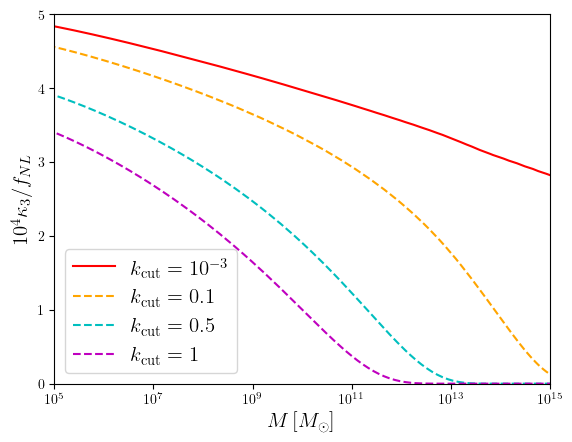

In [50]:
plt.semilogx(Mh, 1e4* kappa3(mu3_all) /fnl_test,'r',label=r'$k_{\rm cut}=10^{-3}$')
plt.semilogx(Mh, 1e4* kappa3(mu3_01)/fnl_test,color='orange',ls='--',label=r'$k_{\rm cut}=0.1$')
plt.semilogx(Mh, 1e4* kappa3(mu3_05)/fnl_test,color='c',ls='--',label=r'$k_{\rm cut}=0.5$')
plt.semilogx(Mh, 1e4*kappa3(mu3_1)/fnl_test,color='m',ls='--',label=r'$k_{\rm cut}=1$')
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$10^4\kappa_3/f_{NL}$',fontsize=15)
plt.legend(fontsize=15)
plt.ylim(0,5)
plt.xlim(1e5,1e15)

plt.savefig(plot_folder + 'kappa_kcut.png')